# Evaluate VAE vs DDPM on Colab


## 1. GPU check and Google Drive

In [10]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount('/content/drive')

CUDA available: True
Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Clone the repo

In [11]:
import os
os.environ["TORCH_HOME"] = "/content/drive/MyDrive/torch_cache"

%cd /content
if not os.path.exists("vae-ddpm-from-scratch"):
    !git clone https://github.com/Besh00Y/vae-ddpm-from-scratch.git
%cd /content/vae-ddpm-from-scratch
!git pull
!pip install -q torch-fidelity pyyaml

/content
/content/vae-ddpm-from-scratch
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 3.77 KiB | 1.89 MiB/s, done.
From https://github.com/Besh00Y/vae-ddpm-from-scratch
   ed34c8b..317a61b  main       -> origin/main
Updating ed34c8b..317a61b
Fast-forward
 .gitignore                  |   4 +-
 evaluate.py                 | 157 ++++++++++++++++++++++++++++++++++++++++++++
 src/evaluation/metrics.py   |  20 ++++++
 src/evaluation/visualize.py |  48 ++++++++++++++
 4 files changed, 228 insertions(+), 1 deletion(-)
 create mode 100644 src/evaluation/metrics.py
 create mode 100644 src/evaluation/visualize.py


## 3. Settings
The latest checkpoint in each folder is used automatically.

In [12]:
VAE_DIR = "/content/drive/MyDrive/vae_ddpm/vae"
DDPM_DIR = "/content/drive/MyDrive/vae_ddpm/ddpm"
RESULTS = "/content/drive/MyDrive/vae_ddpm/results.json"
N = 5000

!ls {VAE_DIR}/checkpoints
!ls {DDPM_DIR}/checkpoints

epoch_10.pt  epoch_20.pt  epoch_30.pt  epoch_40.pt  epoch_50.pt
epoch_15.pt  epoch_25.pt  epoch_35.pt  epoch_45.pt  epoch_5.pt
epoch_10.pt  epoch_20.pt  epoch_30.pt  epoch_40.pt  epoch_50.pt
epoch_15.pt  epoch_25.pt  epoch_35.pt  epoch_45.pt  epoch_5.pt


## 4. Timing test (optional, recommended)
Generates only 250 DDPM images and computes the metrics, so you can estimate how long the full run will take (time scales linearly with N). The FID value here is not meaningful.

In [13]:
%%time
!python evaluate.py --models ddpm --n 250 --ddpm_dir {DDPM_DIR} --gen_root /content/eval_timing --out /content/eval_timing.json

Device: cuda

=== DDPM ===
  250/250
Computing FID / IS ...
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /content/drive/MyDrive/torch_cache/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataL

In [14]:
import json
print(json.dumps(json.load(open("/content/eval_timing.json")), indent=2))

{
  "ddpm": {
    "fid": 112.00346170453099,
    "is_mean": 5.0374472663218866,
    "is_std": 0.6655793662661583,
    "n_generated": 250,
    "reference": "cifar10-train",
    "sec_per_image": 1.0768547095358372,
    "images_per_sec": 0.9286303817448462,
    "train_time_min": 83.46569910446803,
    "params_millions": 8.952067,
    "epochs_trained": 50,
    "device": "cuda"
  }
}


## 5. Full evaluation
Computes FID and Inception Score for both models, plus sampling speed. `--baseline` also scores real test images as a reference. If the session disconnects, rerun cells 1-3 and this cell: generation resumes from the images already saved.

In [15]:
N = 3000

In [16]:
!python evaluate.py --models vae ddpm --n {N} --vae_dir {VAE_DIR} --ddpm_dir {DDPM_DIR} --out {RESULTS} --baseline

Device: cuda
Baseline: real CIFAR-10 test images vs cifar10-train
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_work

In [17]:
import json
with open(RESULTS, encoding="utf-8") as f:
    print(json.dumps(json.load(f), indent=2))

{
  "real_test_baseline": {
    "fid": 3.150838203882529,
    "is_mean": 10.960401572996641,
    "is_std": 0.23457450118617781
  },
  "vae": {
    "fid": 127.32153395327919,
    "is_mean": 3.461015481128134,
    "is_std": 0.0984523412422876,
    "n_generated": 3000,
    "reference": "cifar10-train",
    "sec_per_image": 7.126107811927795e-05,
    "images_per_sec": 14032.905849756913,
    "train_time_min": 14.315008366107941,
    "params_millions": 2.896003,
    "epochs_trained": 50,
    "device": "cuda"
  },
  "ddpm": {
    "fid": 32.217570672829254,
    "is_mean": 6.765007958050349,
    "is_std": 0.3382879287654233,
    "n_generated": 3000,
    "reference": "cifar10-train",
    "sec_per_image": 1.0573320128023624,
    "images_per_sec": 0.9457767171444955,
    "train_time_min": 83.46569910446803,
    "params_millions": 8.952067,
    "epochs_trained": 50,
    "device": "cuda"
  }
}


## 6. Side-by-side comparison figure

100% 170M/170M [17:10<00:00, 165kB/s]
Saved /content/drive/MyDrive/vae_ddpm/comparison.png


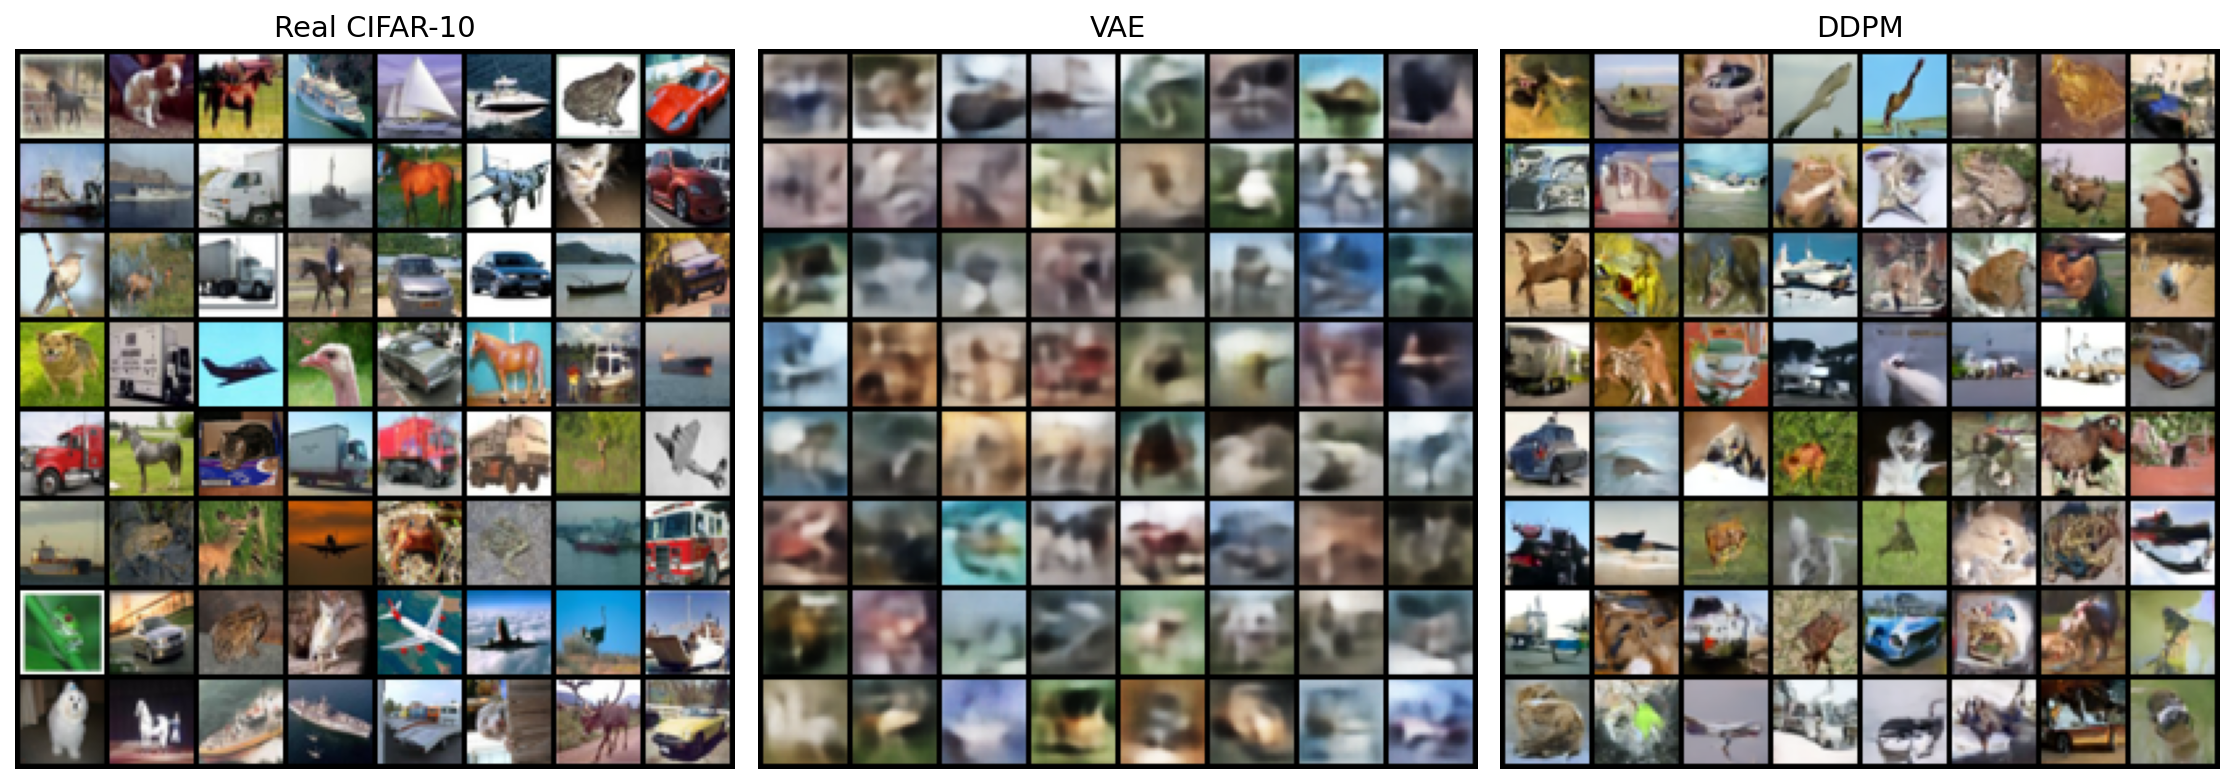

In [18]:
COMPARISON = "/content/drive/MyDrive/vae_ddpm/comparison.png"
!python -m src.evaluation.visualize --vae_gen outputs/generated/vae_{N} --ddpm_gen outputs/generated/ddpm_{N} --out {COMPARISON}

from IPython.display import Image, display
display(Image(COMPARISON))

In [19]:
!rsync -ah --info=progress2 /content/vae-ddpm-from-scratch/outputs/generated/ /content/drive/MyDrive/vae_ddpm/output/

         12.11M 100%  158.96kB/s    0:01:14 (xfr#6000, to-chk=0/6003)
